## Full workflow to run DPAM-AI to identify domains in pacini cancer targets

Input: uniprot_ids mapped from Pacini cancer targets .xls

Workflow:
- split all uniprot_ids into subsets
- run DPAM-AI on slurm as parallel jobs
- Combine and inspect all detected domains

Output: .csv file containing all domains with their residue ranges and sequences

________
### Step 1 - Split all uniprot_ids into subsets and prepare input .pdb and .json files for DPAM-AI

In [1]:
import os
import sys

# Always work from top-level directory
root_dir = !git rev-parse --show-toplevel
os.chdir(root_dir[0])

In [2]:
import pandas as pd

# Read the Pacini cancer targets-UniProt mapping file
df_pacini = pd.read_csv('notebooks/Pacini_target_UniProt_mapping.csv')
df_pacini.head()

,target,uniprot_id
0,KRAS,P01116
1,FLT3,P36888
2,HDAC7,Q8WUI4
3,NDUFC1,O43677
4,ATP1A1,P05023


In [3]:
# Split all uniprot_ids into subsets, then write to subset<n>_struc.list in data_dir
data_dir = 'pacini_results'
n_subsets = 500

os.makedirs(data_dir, exist_ok=True)

all_uniprot_ids = df_pacini['uniprot_id'].tolist()

for i in range(n_subsets):
    subset_uniprot_ids = all_uniprot_ids[i::n_subsets]
    with open(f'{data_dir}/subset_{i}_struc.list', 'w') as f:
        for uniprot_id in subset_uniprot_ids:
            f.write(f'{uniprot_id}\n')

______
### Step 2 - run DPAM-AI on slurm as parallel jobs

In [4]:
# Run DPAM-AI on slurm as parallel jobs
# !sbatch --array=1-$n_subsets%10 scripts/slurm/run_dpam_singularity_array.sh

________
### Step 3 - Read and inspect DPAM-AI results

In [56]:
# Read all *_domains files in data_dir
domains_files = os.listdir(data_dir)
domains_files = [f for f in domains_files if f.endswith('_domains')]

# Read all domains files into a single dataframe
df_domains = pd.DataFrame()
for file in domains_files:
    df = pd.read_csv(os.path.join(data_dir, file), sep='\t')
    subset = str.replace(file, '_domains', '') # keep track of the subset number to find the corresponding pdb file
    df['subset'] = subset
    df_domains = pd.concat([df_domains, df])

df_domains.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.0,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415
3,P05771,nD1,31-95,167536,e2ennA1,376.1.2,0.997,0.878,9.2,0.829,1.048,good_domain,0,4,subset_415
4,P05771,nD2,96-155,2581364,e6ra0A2,376.1.2,0.996,0.937,9.1,1.0,0.968,simple_topology,0,2,subset_415


In [57]:
# Save the dataframe to a csv file
out_dir = 'output'
os.makedirs(out_dir, exist_ok=True)
df_domains.to_csv(os.path.join(out_dir, 'pacini_domains.csv'), index=False)

In [38]:
# Read the pacini_domains.csv file
import pandas as pd
out_dir = 'output'
df_domains = pd.read_csv(os.path.join(out_dir, 'pacini_domains.csv'))

# Convert numeric columns to float
numeric_cols = ['DPAM_prob', 'HH_prob', 'DALI_zscore', 'Hit_cov', 'Tgroup_cov']
df_domains[numeric_cols] = df_domains[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Convert integer columns to int
int_cols = ['Hcount', 'Scount']
df_domains[int_cols] = df_domains[int_cols].astype(int)


In [4]:
# Function to subset df_domains to a specific protein
def subset_df_domains(df_domains, protein_id):
    return df_domains[df_domains['Protein'] == protein_id]

# Example usage
subset_df_domains(df_domains, 'P19801')

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset
0,P19801,nD1,31-140,1149190,e3hi7A6,243.5.1,0.998,1.0,10.4,0.909,0.909,good_domain,2,5,subset_415
1,P19801,nD2,141-285,1149189,e3hi7A5,243.5.1,0.998,1.0,20.2,0.837,1.198,good_domain,4,5,subset_415
2,P19801,nD3,301-750,1149188,e3hi7A4,12.3.1,1.000,1.0,46.3,0.996,1.601,good_domain,4,25,subset_415


In [6]:
import py3Dmol

data_dir = 'pacini_results'

# Function to visualize protein domains
def visualize_protein_domains(df_protein, data_dir, Domain=None):
    """
    Visualizes protein domains from a DataFrame row subset using py3Dmol.

    Args:
        df_protein (pd.DataFrame): Subset of domains DataFrame for a specific protein.
                                  Must have columns 'Domain', 'Range', 'Judge', and 'Protein'.
        data_dir (str): Path to the directory containing the pdb files.
        Domain (str, optional): Highlight this domain in red; others are colored with low-saturation colors.

    Returns:
        py3Dmol.view: The rendered 3Dmol.js view object.
    """
    # Distinct, saturated colors for multiple domains
    domain_colors = [
        'red', 'green', 'blue', 'orange', 'magenta', 'cyan', 'yellow', 'purple', 'brown', 'lime'
    ]
    # Low-saturation/pastel colors for background domains
    pale_colors = [
        '#FFB6B6',  # pale pink
        '#C6E2FF',  # pale blue
        '#B4EEB4',  # pale green
        '#FDFD96',  # pale yellow
        '#FFE4E1',  # misty rose
        '#E6E6FA',  # lavender
        '#FFFACD',  # lemon chiffon
        '#E0FFFF',  # light cyan
        '#F5E6FF',  # pale purple
        '#FFF0F5',  # lavender blush
    ]
    # Color to highlight the selected Domain
    highlight_color = 'blue'

    def parse_ranges(range_string):
        """Return list of (start, end) tuples (1-based inclusive) from a 'Range' string like '6-35,41-410'."""
        res = []
        for part in range_string.split(','):
            start, end = [int(x) for x in part.split('-')]
            res.append((start, end))
        return res

    # Determine model path from DataFrame
    protein_id = df_protein.iloc[0]['Protein']
    # Find the corresponding pdb file in data_dir/step2/subset_<n>/
    model_path = os.path.join(data_dir, f"step2/{df_protein.iloc[0]['subset']}/{protein_id}.pdb")

    view = py3Dmol.view(width=500, height=500)
    view.addModel(open(model_path).read(), 'pdb')

    # Set the default structure color to lightgrey
    view.setStyle({'cartoon': {'color': 'lightgrey'}})

    # Color scheme logic
    for idx, (domain_name, range_str, judge) in enumerate(zip(df_protein['Domain'], df_protein['Range'], df_protein['Judge'])):
        if Domain is None:
            # Legacy: color each domain unique color
            color = domain_colors[idx % len(domain_colors)]
        else:
            # New: color Domain as 'red', others as low-saturation
            if str(domain_name) == str(Domain):
                color = highlight_color
            else:
                # choose a pale color for "background" domains, cycling if more domains than colors
                color = pale_colors[idx % len(pale_colors)]
        domain_ranges = parse_ranges(range_str)
        for start, end in domain_ranges:
            selection = {'resi': list(range(start, end + 1))}
            view.setStyle(selection, {'cartoon': {'color': color}})

    view.zoomTo()
    return view

# example usage
df_protein = df_domains[df_domains['Protein'] == 'Q9P032']
print(df_protein)
visualize_protein_domains(df_protein, data_dir, 'nD1')

     Protein Domain    Range ECOD_num ECOD_key   T-group  DPAM_prob  HH_prob  \
2277  Q9P032    nD1    31-55  1268779  e3wbhA2  7515.1.1      0.012    0.000   
2278  Q9P032    nD2  111-155     2503  e1hlvA1   101.1.1      0.985    0.525   

      DALI_zscore  Hit_cov  Tgroup_cov            Judge  Hcount  Scount  \
2277          2.3      NaN         NaN  simple_topology       1       0   
2278          4.0    0.667       0.616      good_domain       3       0   

         subset  
2277  subset_38  
2278  subset_38  


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# # Interactive plotly scatter plot of DPAM_prob by Judge (categorical)
# import plotly.express as px
# import ipywidgets as widgets

# x_axis = 'Judge'
# y_axis = 'DPAM_prob'
# color_by = 'Judge'

# # Create a strip plot (only raw data points) of DPAM_prob for each Judge category
# fig = px.strip(
#     df_domains,
#     x=x_axis,
#     y=y_axis,
#     color=color_by,
#     hover_data=['Protein', 'Domain', 'Range'],
#     width=800,
#     height=600,
#     stripmode='overlay'
# )
# fig.update_xaxes(type='category')
# fig

In [ ]:
# ----- Interactive scatter plot with py3Dmol view rendering on click -----
import plotly.express as px
import plotly.graph_objs as go
from IPython.display import display, clear_output
import ipywidgets as widgets

def render_plotly_interactive(df_domains, x_axis, y_axis, color_by, data_dir):
    fig = px.strip(
        df_domains,
        x=x_axis,
        y=y_axis,
        color=color_by,
        hover_data=['Protein', 'Domain', 'Range'],
        width=800,
        height=600,
        stripmode='overlay'
    )
    # Provide a row index per point for each trace using the order of df_domains
    for trace in fig.data:
        # Find the corresponding points for this trace (by legendgroup/color)
        mask = (df_domains[color_by] == trace.name) if color_by in df_domains else [True] * len(df_domains)
        trace.customdata = df_domains.index[mask]

    figw = go.FigureWidget(fig)
    
    viewer_output = widgets.Output()
    row_output = widgets.Output()

    def handle_click(trace, points, selector):
        if len(points.point_inds) > 0:
            idx = points.point_inds[0]
            # Defensive: check length of customdata
            if hasattr(trace, 'customdata') and len(trace.customdata) > idx:
                row_idx = trace.customdata[idx]
                # Convert to scalar if it's a numpy array or list
                if hasattr(row_idx, 'item'):
                    row_idx = row_idx.item()
                elif isinstance(row_idx, (list, tuple)) and len(row_idx) > 0:
                    row_idx = row_idx[0]
                row_idx = int(row_idx)
            else:
                return  # Safety net

            clear_output(wait=True)
            display(figw, viewer_output, row_output)

            # Get the row - handle case where loc might return DataFrame (duplicate indices)
            row = df_domains.loc[row_idx]
            if isinstance(row, pd.DataFrame):
                row = row.iloc[0]
            
            # Extract protein_id and Domain as scalars
            protein_id = row['Protein']
            if isinstance(protein_id, pd.Series):
                protein_id = protein_id.iloc[0]
            elif hasattr(protein_id, 'item'):
                protein_id = protein_id.item()
            
            Domain = row['Domain']
            if isinstance(Domain, pd.Series):
                Domain = Domain.iloc[0]
            elif hasattr(Domain, 'item'):
                Domain = Domain.item()
            
            df_protein = df_domains[df_domains['Protein'] == protein_id]

            # Render the corresponding py3Dmol view ABOVE the row info
            with viewer_output:
                viewer_output.clear_output(wait=True)
                view = visualize_protein_domains(
                    df_protein,
                    data_dir,
                    Domain=Domain
                )
                display(view)

            # Show row info BELOW the py3Dmol viewer
            with row_output:
                row_output.clear_output(wait=True)
                print("Clicked point details:")
                print(row)
                print("\nAll domains for this protein:")
                display(df_protein)

    for trace in figw.data:
        trace.on_click(handle_click)

    display(figw, viewer_output, row_output)

    
# Example call:
x_axis = 'Judge'
y_axis = 'DPAM_prob'
color_by = 'Judge'

render_plotly_interactive(
    df_domains,
    x_axis,
    y_axis,
    color_by,
    data_dir
)

FigureWidget({
    'data': [{'alignmentgroup': 'True',
              'boxpoints': 'all',
              'customdata': {'bdata': ('AAABAAIAAwAFAAYABwAIAAkACgALAA' ... 'zJDMoMywzMDM0MzgzQDNEM0gzTDNQM'),
                             'dtype': 'i2'},
              'fillcolor': 'rgba(255,255,255,0)',
              'hoveron': 'points',
              'hovertemplate': ('Judge=%{x}<br>DPAM_prob=%{y}<b' ... '{customdata[2]}<extra></extra>'),
              'legendgroup': 'good_domain',
              'line': {'color': 'rgba(255,255,255,0)'},
              'marker': {'color': '#636efa'},
              'name': 'good_domain',
              'offsetgroup': 'good_domain',
              'orientation': 'v',
              'pointpos': 0,
              'showlegend': True,
              'type': 'box',
              'uid': 'b732bbda-2026-49d2-99b8-766ffc4cff6a',
              'x': array(['good_domain', 'good_domain', 'good_domain', ..., 'good_domain',
                          'good_domain', 'good_domain'], shap

Output()

Output()

In [48]:
# Ensure DPAM_prob is numeric for comparison
df_domains['DPAM_prob'] = pd.to_numeric(df_domains['DPAM_prob'], errors='coerce')

# Drop rows with missing or invalid DPAM_prob values before searching for min
df_domains_valid = df_domains.dropna(subset=['DPAM_prob'])

df_domains_valid.sort_values(by='DPAM_prob', ascending=True, inplace=True)
df_domains_valid.head()


/tmp/ipykernel_603347/240938606.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset
5,Q9P032,NaN,31-55,1268779,e3wbhA2,7515.1.1,0.012,0.0,2.3,na,na,simple_topology,1,0,subset_38
7,Q99250,NaN,61-95,2436450,e6hd5t1,109.4.1,0.013,0.0,3.2,na,na,simple_topology,0,1,subset_78
8,O14920,NaN,706-730,1070118,e4jioB1,3285.1.1,0.029,0.0,3.2,na,na,simple_topology,1,0,subset_195
15,Q53GD3,NaN,"56-65,381-440",000167314,e3ce2A1,2498.1.1,0.029,0.0,4.1,na,na,low_confidence,1,3,subset_105
11,P56696,NaN,616-645,002390905,e6fgzA1,6108.1.1,0.031,0.0,3.8,na,na,simple_topology,1,0,subset_104


_____
### Step 4 - convert into a non-redundant domain sequence library

In [39]:
# -------- Functions to deal with gaps in domain ranges --------

# Function to return the number of gaps (count commas)
def num_gaps(range_str):
    return range_str.count(',')

#num_gaps('1-10,15-20,25-30') 


# Function to compute the length of the domain (with gaps)
def domain_length_gap(range_str):
    """
    Calculate the total length of a domain by summing the lengths of all its fragments.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"
        
    Returns:
        int: The total length of the domain
    """
    # Split the range string into individual ranges
    ranges = [tuple(map(int, frag.split('-'))) for frag in range_str.split(',')]
    
    # Calculate the total length of the domain
    total_length = sum(end - start + 1 for start, end in ranges)

    return total_length

# print(domain_length_gap('1-10,15-20,25-30'))

# Function to compute the total length of the domain (continuous)
def domain_length_continuous(range_str):
    """
    Calculate the total length of a domain from the residue with lowest index to the residue with highest index
    across all fragments in the range string.

    Args:
        range_str (str): A string representing the domain range, e.g., "1-10,15-20"

    Returns:
        int: The total (continuous) length of the domain
    """
    # Split the range string into fragments
    fragments = range_str.split(',')
    starts = []
    ends = []
    for frag in fragments:
        frag = frag.strip()
        if '-' in frag:
            start_str, end_str = frag.split('-')
            starts.append(int(start_str))
            ends.append(int(end_str))
        else:
            # In case there is a single residue, e.g., "42"
            starts.append(int(frag))
            ends.append(int(frag))
    min_start = min(starts)
    max_end = max(ends)
    return max_end - min_start + 1

# domain_length_continuous('1-10,15-20,25-30')




In [41]:
# Apply gap_length and num_gaps to df_domains
df_domains['domain_length_gap'] = df_domains['Range'].apply(domain_length_gap)
df_domains['domain_length_continuous'] = df_domains['Range'].apply(domain_length_continuous)
df_domains['gap_length'] = df_domains['domain_length_continuous'] - df_domains['domain_length_gap']
df_domains['num_gaps'] = df_domains['Range'].apply(num_gaps)

# Sort by gap_length
df_domains.sort_values(by='gap_length', ascending=False, inplace=True)
df_domains.head()

,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length_gap,domain_length_continuous,gap_length,num_gaps
2111,Q96N67,nD4,"141-160,206-240,1341-1385,1461-1660",1870489,e5hiuA1,109.4.1,0.983,0.000,7.2,0.342,1.049,good_domain,11,1,subset_366,300,1520,1220,3
375,Q93074,nD3,"116-310,346-435,1006-1235,1271-1325,1336-1640,...",4591,e1uw4B1,109.4.1,0.998,0.000,7.7,0.851,3.182,good_domain,34,1,subset_39,910,1990,1080,5
2110,Q96N67,nD3,"51-90,126-135,551-560,731-855,986-1140,1171-12...",1389149,e4u1dA1,109.4.1,0.983,0.000,8.8,0.529,1.556,good_domain,16,6,subset_366,445,1290,845,6
2068,P54289,nD5,"31-70,706-895,981-1025",002325680,e6fu4A1,223.1.1,0.995,0.965,13.0,0.714,1.884,good_domain,8,16,subset_138,275,995,720,2
1831,Q07864,nD5,"496-775,796-970,1666-1925",1121970,e4m8oA4,304.48.1,1.000,1.000,38.1,0.970,3.272,good_domain,19,22,subset_259,715,1430,715,2


#### 4.1 - Strategy to deal with gaps
- If the gap contains another domain, then merge these two domains

In [75]:
# Function to return gap ranges from a range string
def get_gap_range(range_str):
    fragments = [frag.strip() for frag in range_str.split(',')]
    gap_ranges = []
    for i in range(len(fragments) - 1):
        prev_end = int(fragments[i].split('-')[1])
        next_start = int(fragments[i+1].split('-')[0])
        gap_ranges.append(f"{prev_end+1}-{next_start-1}")
    return ','.join(gap_ranges) if gap_ranges else None

#get_gap_range('1-10,15-20,25-30')

# Function to check if any segment within a domain range is enclosed by any gap range(s)
def is_enclosed_by_gap(domain_range, gap_range):
    """
    For a given domain_range (comma-separated possibly multiple segments) and one or more gap_ranges (str, e.g. "30-50,200-210"),
    return True if any segment of domain_range is fully enclosed by any of the gap_ranges.
    E.g., '31-49,100-110', '30-50' -> returns True (because 31-49 is inside 30-50)
    """
    # Handle multiple gap segments
    gap_segments = [g.strip() for g in gap_range.split(',')]
    gap_tuples = []
    for g in gap_segments:
        if '-' in g:
            gap_start, gap_end = map(int, g.split('-'))
        else:
            gap_start = gap_end = int(g)
        gap_tuples.append((gap_start, gap_end))
    # Now check each domain segment against each gap segment
    for segment in domain_range.split(','):
        seg = segment.strip()
        if '-' in seg:
            domain_start, domain_end = map(int, seg.split('-'))
        else:
            domain_start = domain_end = int(seg)
        for gap_start, gap_end in gap_tuples:
            if gap_start <= domain_start and gap_end >= domain_end:
                return True
    return False

# This should return True because 31-49 is enclosed by 30-50
print(is_enclosed_by_gap(
    domain_range='31-49,100-110',
    gap_range='30-50,200-210'))


True


In [ ]:
# ---- If the gap contains another domain, then merge these two domains ----
# Example:
df_protein = df_domains[df_domains['Protein'] == 'P40394']
print(df_protein)
visualize_protein_domains(df_protein, data_dir, 'nD1')




# for each gap, check if it contains another domain
domains_to_merge = []
domains = df_protein['Domain'].unique()
for domain in domains:
    ranges = df_protein[df_protein['Domain'] == domain]['Range']
    range_str = ranges.values[0]
    gap = get_gap_range(df_protein[df_protein['Domain'] == domain]['Range'].values[0])
    if gap is not None:
        # check if the gap contains any other domain in the df_protein
        for other_domain in domains:
            if other_domain != domain:
                other_ranges = df_protein[df_protein['Domain'] == other_domain]['Range']
                other_range_str = other_ranges.values[0]
                if is_enclosed_by_gap(other_range_str, gap):
                    print(f"Gap {gap} in domain {domain} contains domain {other_domain}")
                    domains_to_merge.append((domain, other_domain))

# Deduplicate domains_to_merge (order does not matter for each pair)
domains_to_merge = list({tuple(sorted(pair)) for pair in domains_to_merge})


print(domains_to_merge)

     Protein Domain           Range ECOD_num ECOD_key   T-group  DPAM_prob  \
1056  P40394    nD1  16-175,356-385      452  e2jhfA1   236.1.1      0.998   
1057  P40394    nD2    6-15,176-355     9018  e2jhfA2  2003.1.1      0.996   

      HH_prob  DALI_zscore  Hit_cov  Tgroup_cov        Judge  Hcount  Scount  \
1056      1.0         32.6     0.96       1.098  good_domain       3      10   
1057      1.0         27.8     1.00       0.969  good_domain       7       6   

          subset  domain_length_gap  domain_length_continuous  gap_length  \
1056  subset_241                190                       370         180   
1057  subset_241                190                       350         160   

      num_gaps  
1056         1  
1057         1  
Gap 176-355 in domain nD1 contains domain nD2
Gap 16-175 in domain nD2 contains domain nD1
[('nD1', 'nD2')]


In [56]:
df_domains[(df_domains['gap_length'] < 200) & (df_domains['domain_length_gap'] < 200)].head()


,Protein,Domain,Range,ECOD_num,ECOD_key,T-group,DPAM_prob,HH_prob,DALI_zscore,Hit_cov,Tgroup_cov,Judge,Hcount,Scount,subset,domain_length_gap,domain_length_continuous,gap_length,num_gaps
2027,Q8TBC4,nD2,"26-35,231-310",1870427,e1yovB3,6076.1.1,0.995,1.000,18.2,1.000,0.610,good_domain,4,0,subset_113,90,285,195,1
1804,Q14839,nD9,"1491-1510,1696-1800",1159966,e4b4cA5,101.1.1,0.998,0.985,8.7,0.786,1.712,good_domain,5,0,subset_283,125,310,185,1
1056,P40394,nD1,"16-175,356-385",452,e2jhfA1,236.1.1,0.998,1.000,32.6,0.960,1.098,good_domain,3,10,subset_241,190,370,180,1
365,P48058,nD4,"531-570,591-650,806-865",002821689,e7rz5A1,5054.1.1,0.999,1.000,19.3,0.417,0.702,good_domain,5,0,subset_381,160,335,175,2
2464,P08253,nD3,"116-215,391-460",1410803,e1su3A3,2498.1.1,0.998,1.000,28.0,0.988,0.677,good_domain,3,6,subset_54,170,345,175,1


In [59]:
df_protein = df_domains[df_domains['Protein'] == 'P40394']
print(df_protein)
visualize_protein_domains(df_protein, data_dir, 'nD1')

     Protein Domain           Range ECOD_num ECOD_key   T-group  DPAM_prob  \
1056  P40394    nD1  16-175,356-385      452  e2jhfA1   236.1.1      0.998   
1057  P40394    nD2    6-15,176-355     9018  e2jhfA2  2003.1.1      0.996   

      HH_prob  DALI_zscore  Hit_cov  Tgroup_cov        Judge  Hcount  Scount  \
1056      1.0         32.6     0.96       1.098  good_domain       3      10   
1057      1.0         27.8     1.00       0.969  good_domain       7       6   

          subset  domain_length_gap  domain_length_continuous  gap_length  \
1056  subset_241                190                       370         180   
1057  subset_241                190                       350         160   

      num_gaps  
1056         1  
1057         1  


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Text(0.5, 0, 'Gap Length')

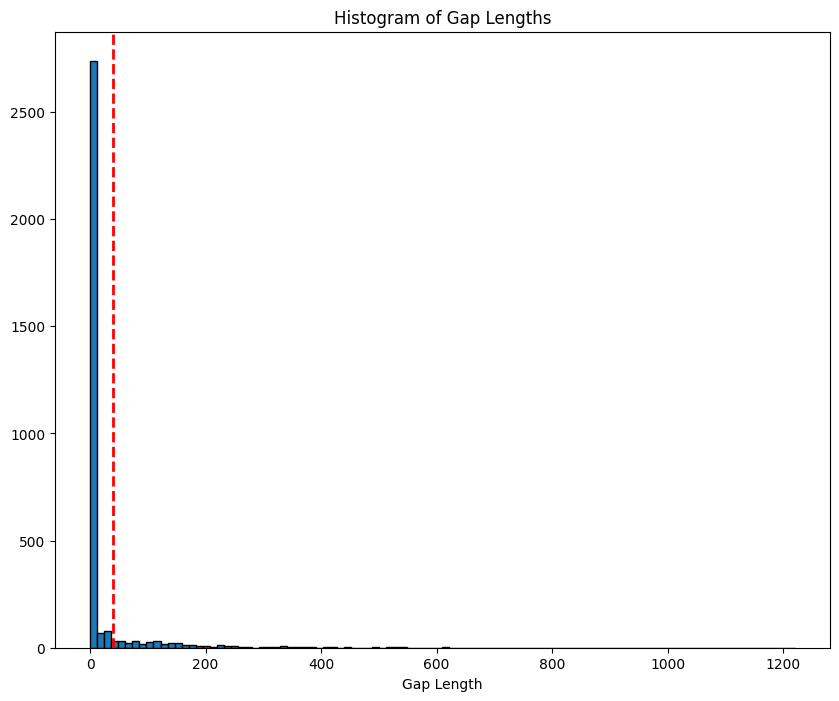

In [53]:
# histogram of gap_length
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.hist(df_domains['gap_length'], bins=100, edgecolor='black')
plt.axvline(x=40, color='red', linestyle='--', linewidth=2)  # Vertical line at x=30
plt.title('Histogram of Gap Lengths')
plt.xlabel('Gap Length')

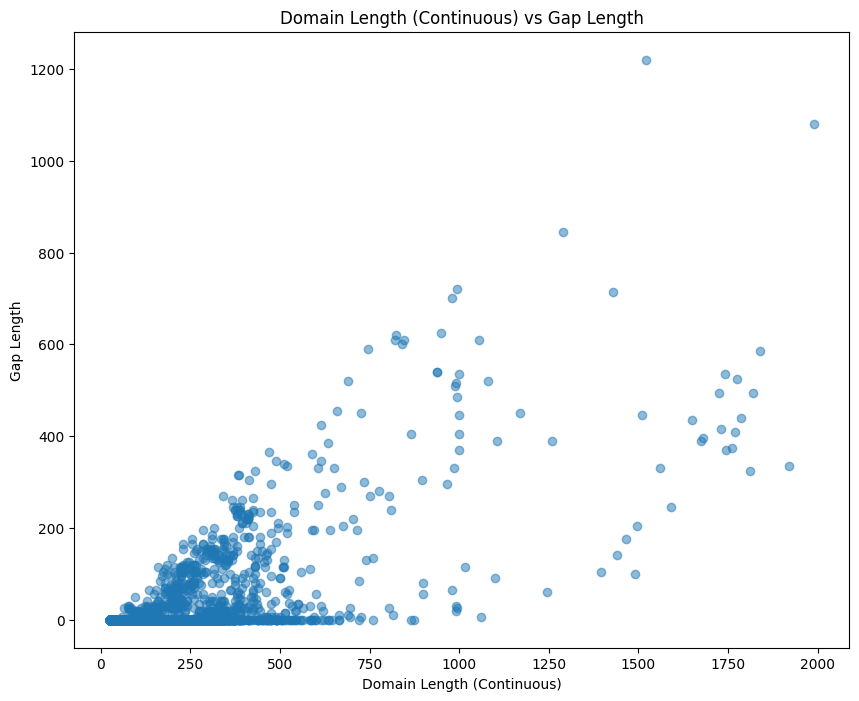

In [49]:
# plot domain_length_continuous vs gap_length
plt.figure(figsize=(10, 8))
plt.scatter(df_domains['domain_length_continuous'], df_domains['gap_length'], alpha=0.5)
plt.xlabel('Domain Length (Continuous)')
plt.ylabel('Gap Length')
plt.title('Domain Length (Continuous) vs Gap Length')
plt.show()